In [1]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preparation

### **1. Importing data**

Here we import our excel data from the different "Sheets" and check the columns that exist in each

In [2]:
# Importing data

# From Sheet1 = Customers
customers = pd.read_excel('Cookie_Company_Data.xlsx', sheet_name='Customers')
print("Columns from the customers data:")
print("------------------------------------")
print(customers.columns.tolist(), "\n")
print(f"Rows and Columns in customers data: {customers.shape}\n")

# From Sheet2 = Orders
orders = pd.read_excel('Cookie_Company_Data.xlsx', sheet_name='Orders')
print("Columns from the orders data:")
print("------------------------------------")
print(orders.columns.tolist(), "\n")
print(f"Rows and Columns in orders data: {orders.shape}\n")


Columns from the customers data:
------------------------------------
['Customer ID', 'Customer Name', 'Country'] 

Rows and Columns in customers data: (50, 3)

Columns from the orders data:
------------------------------------
['Order ID', 'Customer ID', 'Order Date', 'Cookies Shipped', 'Revenue', 'Rush Shipment'] 

Rows and Columns in orders data: (200, 6)



### **2. Renaming the column**

Here we rename our columns into a more appropriate way

In [3]:
# Renaming columns
customers.rename(columns={
    'Customer ID': 'Customer_ID',
    'Customer Name': 'Customer_Name'}, inplace=True)
print("Renamed columns in customers data:")
print(customers.columns.tolist(), "\n")

orders.rename(columns={
    'Order ID': 'Order_ID',
    'Customer ID': 'Customer_ID',
    'Order Date': 'Order_Date',
    'Cookies Shipped': 'Cookies_Shipped',
    'Rush Shipment': 'Rush_Shipment'}, inplace=True)
print("Renamed columns in orders data:")
print(orders.columns.tolist(), "\n")

Renamed columns in customers data:
['Customer_ID', 'Customer_Name', 'Country'] 

Renamed columns in orders data:
['Order_ID', 'Customer_ID', 'Order_Date', 'Cookies_Shipped', 'Revenue', 'Rush_Shipment'] 



### **3. Viewing the first few row**

Here we view the first 5 rows from both dataset

In [4]:
# Viewing the top rows

print("First 5 rows of Customers data")
print("--------------------------------------")
print(customers.head(), "\n")

print("First 5 rows of Orders data")
print("--------------------------------------")
print(orders.head())

First 5 rows of Customers data
--------------------------------------
  Customer_ID                    Customer_Name        Country
0    CUST-001  Rodriguez, Figueroa and Sanchez  United States
1    CUST-002                        Doyle Ltd  United States
2    CUST-003    Mcclain, Miller and Henderson         Canada
3    CUST-004                   Davis and Sons           U.S.
4    CUST-005      Guzman, Hoffman and Baldwin           U.S. 

First 5 rows of Orders data
--------------------------------------
   Order_ID Customer_ID Order_Date  Cookies_Shipped  Revenue Rush_Shipment
0  ORD-0001    CUST-019 2025-02-27              112  4542.45           Yes
1  ORD-0002    CUST-041 2025-01-21              445  1284.00           Yes
2  ORD-0003    CUST-040 2025-04-26              870  2081.40           Yes
3  ORD-0004    CUST-024 2025-01-19              280  3789.98           Yes
4  ORD-0005    CUST-037 2025-05-14              116  1182.55            No


### **4. Relational Mapping (The Join)**

Here we join our 2 datasets to come up with 1

In [5]:
# We use a 'left' join to ensure we keep all order records and attach customer info
df = pd.merge(orders, customers, on='Customer_ID', how='left')
print("First 5 rows of the merged dataset")
print("--------------------------------------")
print(df.head(), "\n")
print(f"Rows and Columns in merged dataset: {df.shape}\n")

First 5 rows of the merged dataset
--------------------------------------
   Order_ID Customer_ID Order_Date  Cookies_Shipped  Revenue Rush_Shipment  \
0  ORD-0001    CUST-019 2025-02-27              112  4542.45           Yes   
1  ORD-0002    CUST-041 2025-01-21              445  1284.00           Yes   
2  ORD-0003    CUST-040 2025-04-26              870  2081.40           Yes   
3  ORD-0004    CUST-024 2025-01-19              280  3789.98           Yes   
4  ORD-0005    CUST-037 2025-05-14              116  1182.55            No   

                 Customer_Name        Country  
0       Adams, Zuniga and Wong  United States  
1                     Ryan PLC         Canada  
2  Romero, Gonzalez and Brooks         Canada  
3                Morales-Jones           U.S.  
4                  Smith-Bowen  United States   

Rows and Columns in merged dataset: (200, 8)



### **5. Checking for missing values and data types**

Here we check the data types to ensure that all columns are saved with the appropriate datatype

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order_ID         200 non-null    object        
 1   Customer_ID      200 non-null    object        
 2   Order_Date       200 non-null    datetime64[ns]
 3   Cookies_Shipped  200 non-null    int64         
 4   Revenue          200 non-null    float64       
 5   Rush_Shipment    200 non-null    object        
 6   Customer_Name    200 non-null    object        
 7   Country          200 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 12.6+ KB
None


There are no missing values in our dataset

### **6. Duplicates**

Here we check whether there are entries that are repeated

In [7]:
df.duplicated().sum()

np.int64(0)

There are no duplicated rows

### **7. Standardizing column entries**

Here we are investigating the different columns to ensure that the entries are uniform

In [8]:
# Country

print(df['Country'].unique(), "\n")
# print(df['Country'].value_counts(), "\n")

# Fix the Country naming inconsistency: "U.S." -> "United States"
df['Country'] = df['Country'].replace('U.S.', 'United States')
print(df['Country'].unique(), "\n")

['United States' 'Canada' 'U.S.' 'United Kingdom' 'Germany'] 

['United States' 'Canada' 'United Kingdom' 'Germany'] 



In [9]:
# Data Quality Check: Fuzzy Matching for Customer Names

from difflib import get_close_matches

# Example
names = df["Customer_Name"].unique()

for name in names:
    matches = get_close_matches(name, names, n=5, cutoff=0.8)
    if len(matches) > 1:
        print(name, "->", matches)
    # else:
    #     print(name, "--> No close matches found")

# Exploratory Data Analysis

In [10]:
# Customers

df["Customer_ID"].nunique()

49

There are 49 customers in our dataset

                Count  Percentage
Country                          
United States     106        53.0
United Kingdom     42        21.0
Canada             26        13.0
Germany            26        13.0


C:\Users\ekiru\AppData\Local\Temp\ipykernel_516\1298392473.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x='Country', order=df['Country'].value_counts().index, palette='tab20')


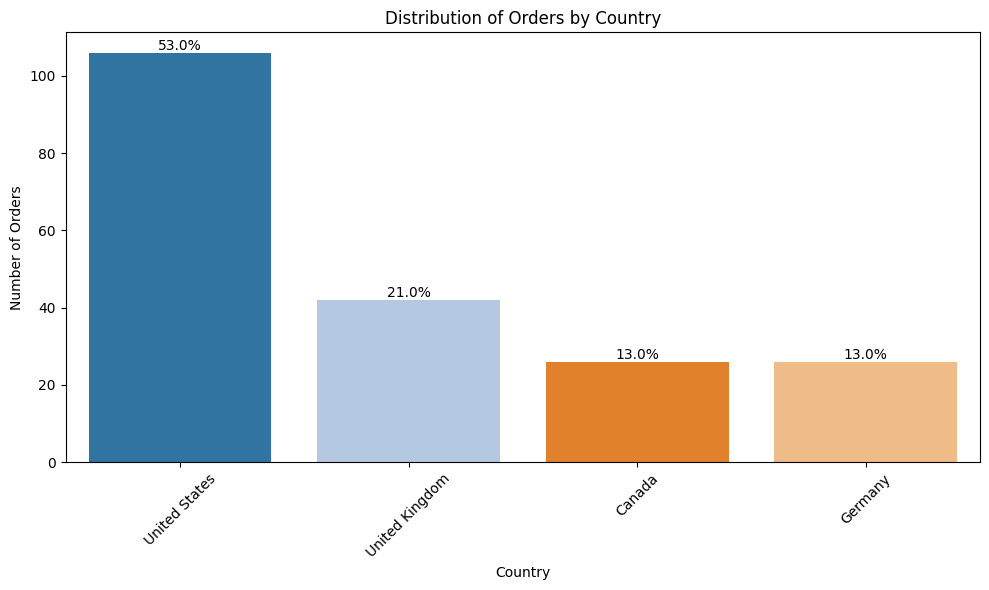

In [11]:
# Country

Country_count = df['Country'].value_counts()
Country_percent = df['Country'].value_counts(normalize=True) * 100

Country_summary = pd.DataFrame({
    'Count': Country_count,
    'Percentage': Country_percent
})
print(Country_summary)

# Bar plot for Country distribution
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='Country', order=df['Country'].value_counts().index, palette='tab20')
plt.title('Distribution of Orders by Country')
plt.xlabel('Country')
plt.ylabel('Number of Orders')
plt.xticks(rotation=45)

# Adding percentages on top of bars
total = len(df)

for p in ax.patches:
    height = p.get_height()
    percentage = (height / total) * 100
    ax.annotate(f'{percentage:.1f}%',
                (p.get_x() + p.get_width()/2, height),
                ha='center',
                va='bottom',
                fontsize=10)

plt.tight_layout()

# Saving the figure
plt.savefig("country_distribution.png", dpi=300)

plt.show()

United states has the biggest cookie customers

C:\Users\ekiru\AppData\Local\Temp\ipykernel_516\2755924778.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


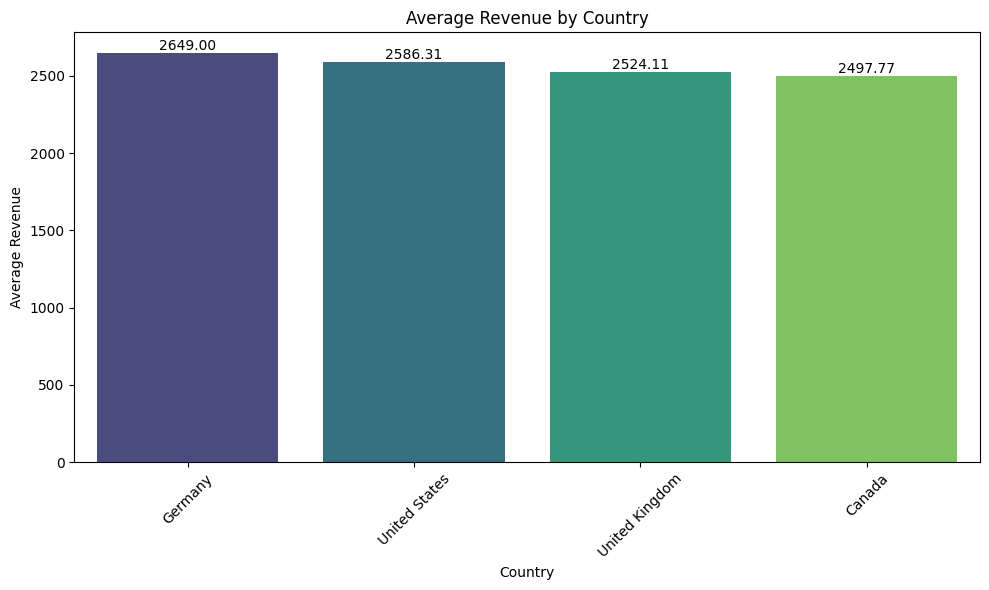

In [ ]:
# Average revenue by Country

avg_revenue_country = df.groupby('Country')['Revenue'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=avg_revenue_country.index,
    y=avg_revenue_country.values,
    palette='viridis'
)

plt.title('Average Revenue by Country')
plt.xlabel('Country')
plt.ylabel('Average Revenue')
plt.xticks(rotation=45)

for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}',
                (p.get_x() + p.get_width()/2, height),
                ha='center',
                va='bottom')

plt.tight_layout()
plt.savefig("average_revenue_by_country.png", dpi=300)
plt.show()

count    200.000000
mean     500.220000
std      289.982917
min       11.000000
25%      250.750000
50%      496.500000
75%      761.750000
max      996.000000
Name: Cookies_Shipped, dtype: float64


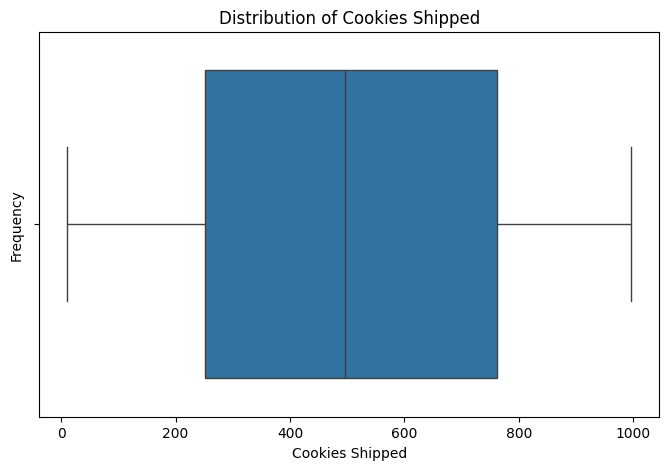

In [13]:
# Cookies Shipped

print(df['Cookies_Shipped'].describe())

# Box plot to check for outliers in Cookies_Shipped
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Cookies_Shipped'])
plt.title('Distribution of Cookies Shipped')
plt.xlabel('Cookies Shipped')
plt.ylabel('Frequency')
plt.show()

count     200.000000
mean     2569.887350
std      1446.532055
min        75.050000
25%      1277.437500
50%      2675.990000
75%      3830.382500
max      4950.770000
Name: Revenue, dtype: float64


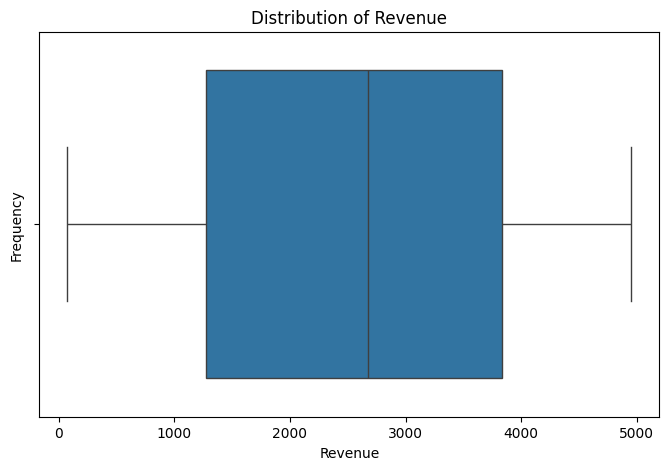

In [14]:
# Revenue distribution

print(df['Revenue'].describe())

# Box plot to check for outliers in Revenue
plt.figure(figsize=(8, 5))
sns.boxplot(x=df['Revenue'])
plt.title('Distribution of Revenue')
plt.xlabel('Revenue')
plt.ylabel('Frequency')
plt.show()

               Count  Percentage
Rush_Shipment                   
Yes              111        55.5
No                89        44.5


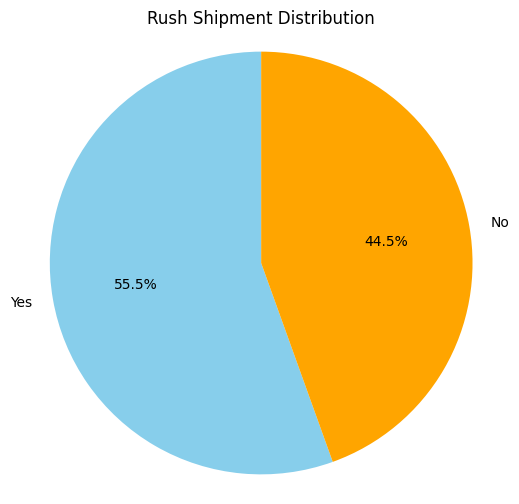

In [15]:
# Rush_Shipment

Rush_Shipment_count = df['Rush_Shipment'].value_counts()
Rush_Shipment_percent = df['Rush_Shipment'].value_counts(normalize=True) * 100

Rush_Shipment_summary = pd.DataFrame({
    'Count': Rush_Shipment_count,
    'Percentage': Rush_Shipment_percent
})
print(Rush_Shipment_summary)

# Pie chart
plt.figure(figsize=(6,6))

plt.pie(
    Rush_Shipment_count,
    labels=Rush_Shipment_count.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['skyblue','orange','lightgreen','pink']
)

plt.title('Rush Shipment Distribution')
plt.axis('equal')  # keeps the pie circular

# Save the figure
plt.savefig("rush_shipment_distribution.png", dpi=300)

plt.show()

Rush_Shipment
No     2454.563371
Yes    2662.354324
Name: Revenue, dtype: float64


C:\Users\ekiru\AppData\Local\Temp\ipykernel_516\3163694492.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


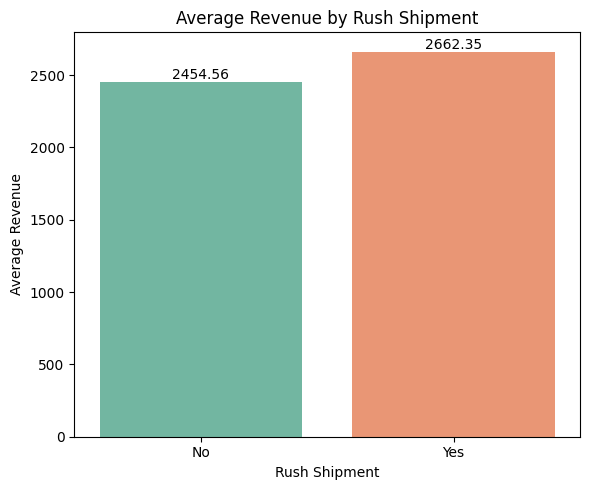

In [ ]:
# Average revenue by Rush Shipment

avg_revenue_rush = df.groupby('Rush_Shipment')['Revenue'].mean()
print(avg_revenue_rush)

plt.figure(figsize=(6,5))

ax = sns.barplot(
    x=avg_revenue_rush.index,
    y=avg_revenue_rush.values,
    palette='Set2'
)

plt.title('Average Revenue by Rush Shipment')
plt.xlabel('Rush Shipment')
plt.ylabel('Average Revenue')

# Add values on top of bars
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height:.2f}',
                (p.get_x() + p.get_width()/2, height),
                ha='center',
                va='bottom')

plt.tight_layout()

# Save the plot
plt.savefig("average_revenue_rush_shipment.png", dpi=300)

plt.show()

### **Generating new variables**

In [17]:
# Revenue per cookie
# This help us understand on average how much each cookie contributes to revenue

# Calculate Revenue per Cookie to help test H3 (Efficiency)
df['Revenue_Per_Cookie'] = df['Revenue'] / df['Cookies_Shipped']
print(df['Revenue_Per_Cookie'].describe())

count    200.000000
mean      12.318539
std       23.667850
min        0.168483
25%        2.615789
50%        5.257509
75%        9.565408
max      157.109091
Name: Revenue_Per_Cookie, dtype: float64


In [18]:
# Create a Month-Year column for easier sorting in the dashboard
df['Month_Year'] = df['Order_Date'].dt.to_period('M')
print(df['Month_Year'].head())

0    2025-02
1    2025-01
2    2025-04
3    2025-01
4    2025-05
Name: Month_Year, dtype: period[M]


In [19]:
# Verifying changes
print(f"Total Records: {len(df)}")
print(f"Unique Countries: {df['Country'].unique()}")
print(df.head())

Total Records: 200
Unique Countries: ['United States' 'Canada' 'United Kingdom' 'Germany']
   Order_ID Customer_ID Order_Date  Cookies_Shipped  Revenue Rush_Shipment  \
0  ORD-0001    CUST-019 2025-02-27              112  4542.45           Yes   
1  ORD-0002    CUST-041 2025-01-21              445  1284.00           Yes   
2  ORD-0003    CUST-040 2025-04-26              870  2081.40           Yes   
3  ORD-0004    CUST-024 2025-01-19              280  3789.98           Yes   
4  ORD-0005    CUST-037 2025-05-14              116  1182.55            No   

                 Customer_Name        Country  Revenue_Per_Cookie Month_Year  
0       Adams, Zuniga and Wong  United States           40.557589    2025-02  
1                     Ryan PLC         Canada            2.885393    2025-01  
2  Romero, Gonzalez and Brooks         Canada            2.392414    2025-04  
3                Morales-Jones  United States           13.535643    2025-01  
4                  Smith-Bowen  United States

### **Saving as csv**

This excel is now ready to be uploaded to Power BI for visuals

In [20]:
# Save the cleaned master file for Power BI
df.to_csv('Cleaned_Cookie_Data.csv', index=False)

# Statistical testing and hypothesis testing

In [21]:
# H1: Testing Geographic Variance
h1_analysis = df.groupby('Country')['Revenue'].agg(['mean', 'count'])
print("H1 - Average Revenue by Country:\n", h1_analysis.sort_values(by='mean', ascending=False))

from scipy import stats

# ANOVA Test

# Null (H0): Mean revenue is identical across all countries.
groups_h1 = [df[df['Country'] == c]['Revenue'] for c in df['Country'].unique()]
f_stat_h1, p_val_h1 = stats.f_oneway(*groups_h1)
print(f"\nANOVA results for H1 - F-statistic: {f_stat_h1:.2f}, p-value: {p_val_h1:.4f}")

H1 - Average Revenue by Country:
                        mean  count
Country                           
Germany         2648.999231     26
United States   2586.308962    106
United Kingdom  2524.109524     42
Canada          2497.774615     26

ANOVA results for H1 - F-statistic: 0.07, p-value: 0.9783


**Finding:** Germany is the highest-value market per order (Avg: $2,648), while Canada is the lowest (Avg: $2,497).

**Insight:** Although the United States generates the most total revenue due to volume (106 orders), German customers spend more on average every time they place an order.

**Recommendation:** Target Germany for "High-Value" loyalty programs.

### **However**

**ANOVA Interpretation:** Since the p-value (0.9783) is not less than 0.05, we fail to reject the null that states; There is no significant mean difference in the average order value across different countries.

Therefore, An order from Canada is fundamentally worth the same as an order from Germany.

In [22]:
# 2. H2: Testing Logistics Premium (Rush vs Regular)
h2_analysis = df.groupby('Rush_Shipment')['Revenue'].agg(['mean', 'median', 'count'])
print("\nH2 - Impact of Rush Shipping:\n", h2_analysis)

# T-test

# Null (H0): Mean revenue is the same for Rush and Regular shipments.
rush_rev = df[df['Rush_Shipment'] == 'Yes']['Revenue']
reg_rev = df[df['Rush_Shipment'] == 'No']['Revenue']
t_stat_h2, p_val_h2 = stats.ttest_ind(rush_rev, reg_rev)
print(f"\nT-test results for H2 - t-statistic: {t_stat_h2:.2f}, p-value: {p_val_h2:.4f}")


H2 - Impact of Rush Shipping:
                       mean   median  count
Rush_Shipment                             
No             2454.563371  2472.79     89
Yes            2662.354324  2798.24    111

T-test results for H2 - t-statistic: 1.01, p-value: 0.3139


**Finding:** Rush Shipments yield an average revenue of $2,662, compared to $2,454 for regular shipments.

**Insight:** Rush shipments are not just an operational burden; they are associated with higher-value transactions (roughly $200 more per order).

### **However**

**t-test interpretation:** Since the p-value (0.3139) is greater less than   0.05, we fail to reject the null that states; There is no significant difference in average revenue between Rush (Yes) shipments and Regular (No) shipments.

Therefore, "Rush" orders do not bring in more money than regular orders. The perceived "Logistics Premium" is likely just random noise.

**Recommendation:** The company should regulate "Rush (Yes) shipments" of cookies as a premium service and instead encourage "Regular (No)" shipments.

In [23]:
# 3. H3: Testing Operational Efficiency (Revenue per Cookie)
h3_analysis = df.groupby('Country').agg({
    'Cookies_Shipped': 'sum',
    'Revenue': 'sum',
    'Revenue_Per_Cookie': 'mean'
}).sort_values(by='Revenue_Per_Cookie', ascending=False)
print("\nH3 - Revenue Density per Cookie:\n", h3_analysis)


# ANOVA test

# Null (H0): Mean 'Revenue per Cookie' is identical across all countries.
groups_h3 = [df[df['Country'] == c]['Revenue_Per_Cookie'] for c in df['Country'].unique()]
f_stat_h3, p_val_h3 = stats.f_oneway(*groups_h3)
print(f"\nT-test results for H2 - t-statistic: {t_stat_h2:.2f}, p-value: {p_val_h2:.4f}")


H3 - Revenue Density per Cookie:
                 Cookies_Shipped    Revenue  Revenue_Per_Cookie
Country                                                       
Canada                    11819   64942.14           16.351905
Germany                   12765   68873.98           13.957172
United Kingdom            21338  106012.60           13.583955
United States             54122  274148.75           10.425902

T-test results for H2 - t-statistic: 1.01, p-value: 0.3139


**Finding:** Canada has the highest "Revenue Per Cookie" ($16.35), while the United States has the lowest ($10.42).

**Insight:** There exits a big "Mismatch." The US is shipping massive volumes but at a much lower revenue density per unit.

### **However**

**ANOVA interpretation:** Since the p-value (0.3139) is greater less than    0.05, we fail to reject the null that states; Shipping volume in a region is proportional to its generated revenue, indicating no mismatch between operational activity and revenue generation.

Profitability per cookie is consistent across borders. No country is significantly more "efficient" than another.

**Recommendation:** Investigate pricing in the US. The company is doing a lot of work (shipping 54k cookies) for a lower margin compared to the Canadian market.